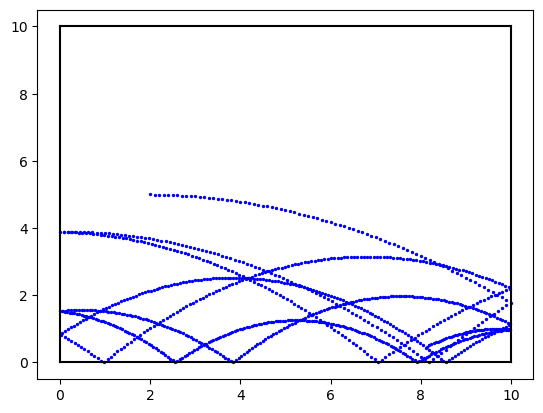

In [39]:
import numpy as np
import matplotlib.pyplot as plt

t = 0
dt = 0.01

pos = [2, 5]
vel = [10, 0]
acc = [0, -9.81]

E_loss_factor = 0.9

while t < 10:

    plt.scatter(pos[0], pos[1], color='b', s=2)

    vel[0] += acc[0]*dt
    vel[1] += acc[1]*dt

    pos[0] += vel[0]*dt + 0.5*acc[0]*dt**2
    pos[1] += vel[1]*dt + 0.5*acc[1]*dt**2


    if pos[0] > 10:
        pos[0] = 20 - pos[0]
        vel[0] = E_loss_factor*-vel[0]
    
    if pos[0] < 0:
        pos[0] = -pos[0]
        vel[0] = E_loss_factor*-vel[0]

    if pos[1] > 10:
        pos[1] = 20 - pos[1]
        vel[1] = E_loss_factor*-vel[1]
    
    if pos[1] < 0:
        pos[1] = -pos[1]
        vel[1] = E_loss_factor*-vel[1]

    t += dt

# bottom = np.linspace(0,10,100)
# top = np.linspace(0,10,100)

plt.plot([0,10], [0,0], c='k')
plt.plot([0,10], [10,10],c='k')
plt.plot([0,0], [0,10],c='k')
plt.plot([10,10], [0,10],c='k')
plt.show()

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Parameters
t = 0
dt = 0.01
total_time = 10
num_frames = int(total_time / dt)

# Initial conditions
pos = [2, 5]
vel = [10, 0]
acc = [0, -9.81]

E_loss_factor = 0.9

# Function to create a frame
def create_frame(pos):
    img = Image.new('RGB', (500, 500), 'white')
    draw = ImageDraw.Draw(img)
    
    # Draw the walls
    draw.line([(50, 50), (450, 50)], fill='black')
    draw.line([(50, 50), (50, 450)], fill='black')
    draw.line([(450, 50), (450, 450)], fill='black')
    draw.line([(50, 450), (450, 450)], fill='black')
    
    # Draw the position
    x = int(50 + pos[0] * 40)
    y = int(450 - pos[1] * 40)
    draw.ellipse([(x - 5, y - 5), (x + 5, y + 5)], fill='blue')
    
    return img

# Create frames for animation
frames = []

for _ in range(num_frames):
    frames.append(create_frame(pos))
    
    vel[0] += acc[0] * dt
    vel[1] += acc[1] * dt
    
    pos[0] += vel[0] * dt + 0.5 * acc[0] * dt**2
    pos[1] += vel[1] * dt + 0.5 * acc[1] * dt**2
    
    if pos[0] > 10:
        pos[0] = 20 - pos[0]
        vel[0] = E_loss_factor * -vel[0]
    
    if pos[0] < 0:
        pos[0] = -pos[0]
        vel[0] = E_loss_factor * -vel[0]

    if pos[1] > 10:
        pos[1] = 20 - pos[1]
        vel[1] = E_loss_factor * -vel[1]
    
    if pos[1] < 0:
        pos[1] = -pos[1]
        vel[1] = E_loss_factor * -vel[1]

    t += dt

# Save the frames as a GIF
frames[0].save('bouncing_ball.gif', save_all=True, append_images=frames[1:], duration=dt * 1000, loop=0)
